In [ ]:
# Cell 1: Libraries & Data Cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
# New Libraries based on Rubric
from sklearn.decomposition import PCA, KernelPCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Data
try:
    df = pd.read_csv('AswanData_weatherdata.csv')
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

    # --- Missing Values Treatment (REQUIRED BY RUBRIC) ---
    print("Checking for missing values...")
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"Found {missing_count} missing values. Filling with median...")
        df.fillna(df.median(numeric_only=True), inplace=True)
    else:
        print("No missing values found. Data is clean.")

    print(f"Data Loaded Successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: File not found.")

# Initialize Scaler and Encoder for later
scaler = StandardScaler()
le = LabelEncoder()

Checking for missing values...
No missing values found. Data is clean.
Data Loaded Successfully. Shape: (398, 7)



--- Descriptive Statistics ---
                                                         mean        std  \
Date                            2021-10-26 08:22:54.874371584        NaN   
AvgTemperture                                       81.846482  13.613097   
AverageDew(point via humidity)                       36.75402   8.906835   
Humidity                                             22.96809   9.756598   
Wind                                                10.146734   2.509152   
Pressure                                             29.18304   0.140241   
Solar(PV)                                           24.375258   7.507561   
Month                                                6.188442   3.258342   

                                  variance  skewness  kurtosis  
Date                                   NaN       NaN       NaN  
AvgTemperture                   185.316398 -0.528708 -0.903930  
AverageDew(point via humidity)   79.331709  0.001333 -0.667801  
Humidity               

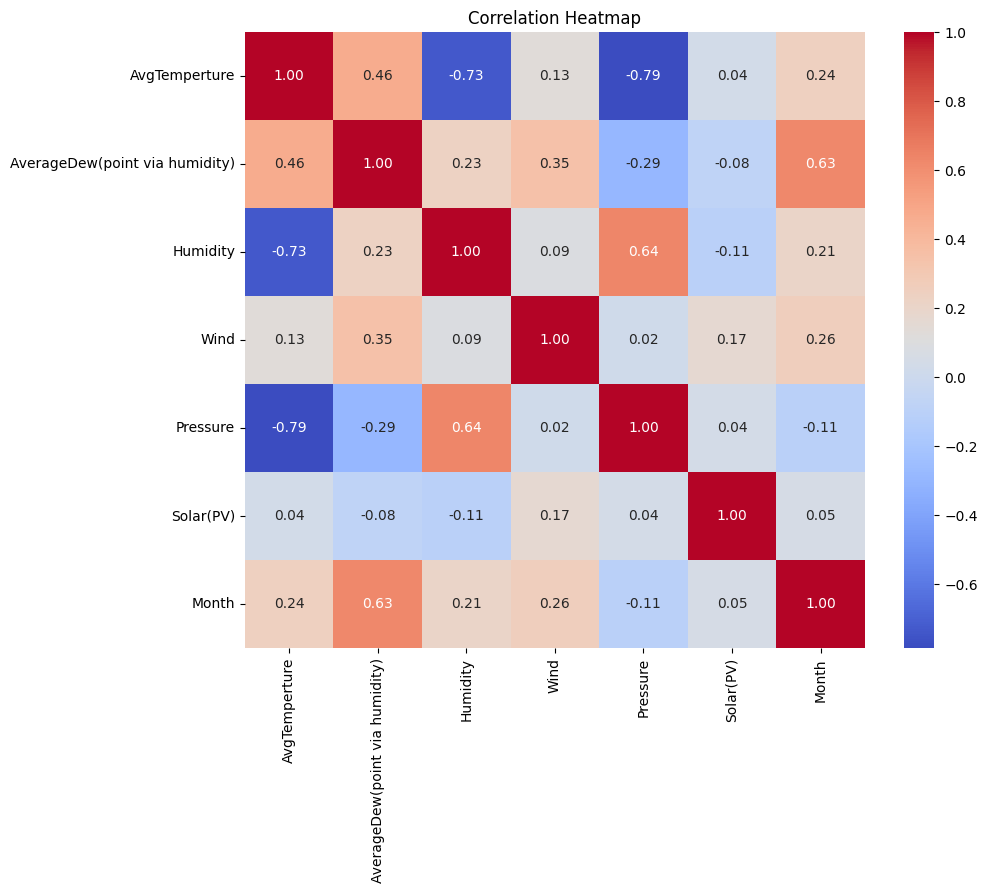

/tmp/ipython-input-4058820356.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Solar_Class', y='AvgTemperture', data=df, palette='Set2')


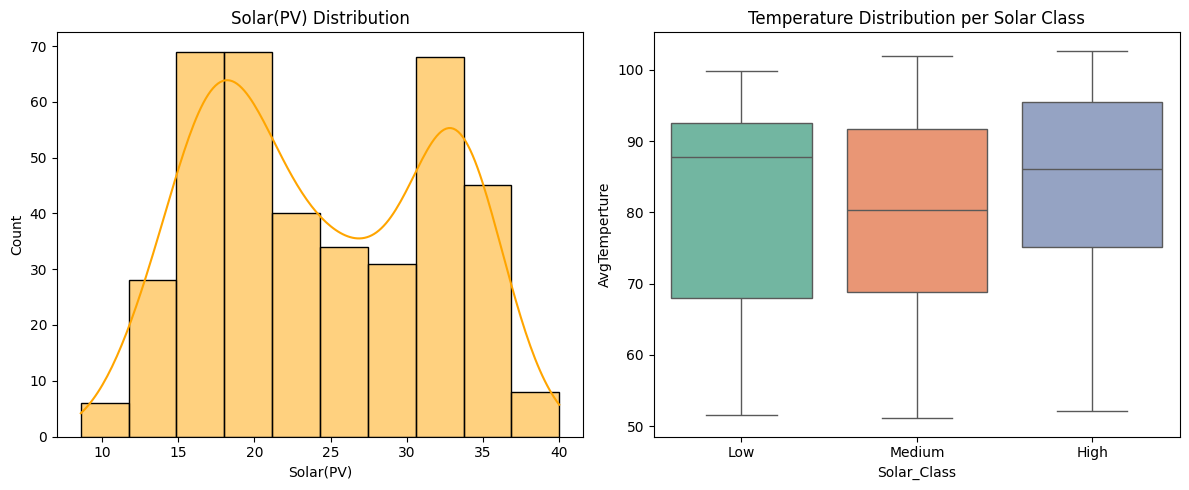


--- Statistical Hypothesis Testing ---
- T-test P-value: 2.7706e-01
- ANOVA P-value: 3.4705e-02
- Chi-Square P-value: 9.0679e-02


In [ ]:
# Cell 2: Advanced Data Analysis (Min, Max, Skewness, Covariance, Tests)

# 1. Feature Engineering (Adding Month)
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# 2. Binning (Required)
df['Solar_Class'] = pd.qcut(df['Solar(PV)'], q=3, labels=['Low', 'Medium', 'High'])
df['Temp_Class'] = pd.qcut(df['AvgTemperture'], q=3, labels=['Low', 'Medium', 'High'])

# 3. Descriptive Statistics
stats_df = df.describe().transpose()
stats_df['variance'] = df.var(numeric_only=True)
stats_df['skewness'] = df.skew(numeric_only=True)
stats_df['kurtosis'] = df.kurtosis(numeric_only=True)
print("\n--- Descriptive Statistics ---")
print(stats_df[['mean', 'std', 'variance', 'skewness', 'kurtosis']])

# 4. Correlation & Covariance (REQUIRED BY RUBRIC)
print("\n--- Covariance Matrix (Top Features) ---")
cov_matrix = df.cov(numeric_only=True)
print(cov_matrix.iloc[:3, :3]) # Showing a sample of Covariance

# Plotting Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# --- إضافة الرسوم البيانية من البروجيكت الأول لضمان بند Data Visualization ---
plt.figure(figsize=(12, 5))

# 1. رسم التوزيع (Histogram)
plt.subplot(1, 2, 1)
sns.histplot(df['Solar(PV)'], kde=True, color='orange')
plt.title('Solar(PV) Distribution')

# 2. رسم الصندوق (Boxplot) لمقارنة الحرارة بالفئات
plt.subplot(1, 2, 2)
sns.boxplot(x='Solar_Class', y='AvgTemperture', data=df, palette='Set2')
plt.title('Temperature Distribution per Solar Class')

plt.tight_layout()
plt.show()

# 5. Statistical Tests
print("\n--- Statistical Hypothesis Testing ---")
group_low = df[df['Solar_Class'] == 'Low']['AvgTemperture']
group_med = df[df['Solar_Class'] == 'Medium']['AvgTemperture']
group_high = df[df['Solar_Class'] == 'High']['AvgTemperture']

# T-test & ANOVA
_, p_val_t = stats.ttest_ind(group_low, group_high)
_, p_val_anova = stats.f_oneway(group_low, group_med, group_high)
# Chi-Square
contingency = pd.crosstab(df['Temp_Class'], df['Solar_Class'])
_, p_val_chi, _, _ = stats.chi2_contingency(contingency)

print(f"- T-test P-value: {p_val_t:.4e}")
print(f"- ANOVA P-value: {p_val_anova:.4e}")
print(f"- Chi-Square P-value: {p_val_chi:.4e}")


--- 1. Advanced Feature Reduction ---
PCA Explained Variance Ratio: 0.7507
LDA Explained Variance Ratio: 1.0000
SVD Explained Variance Ratio: 0.7507


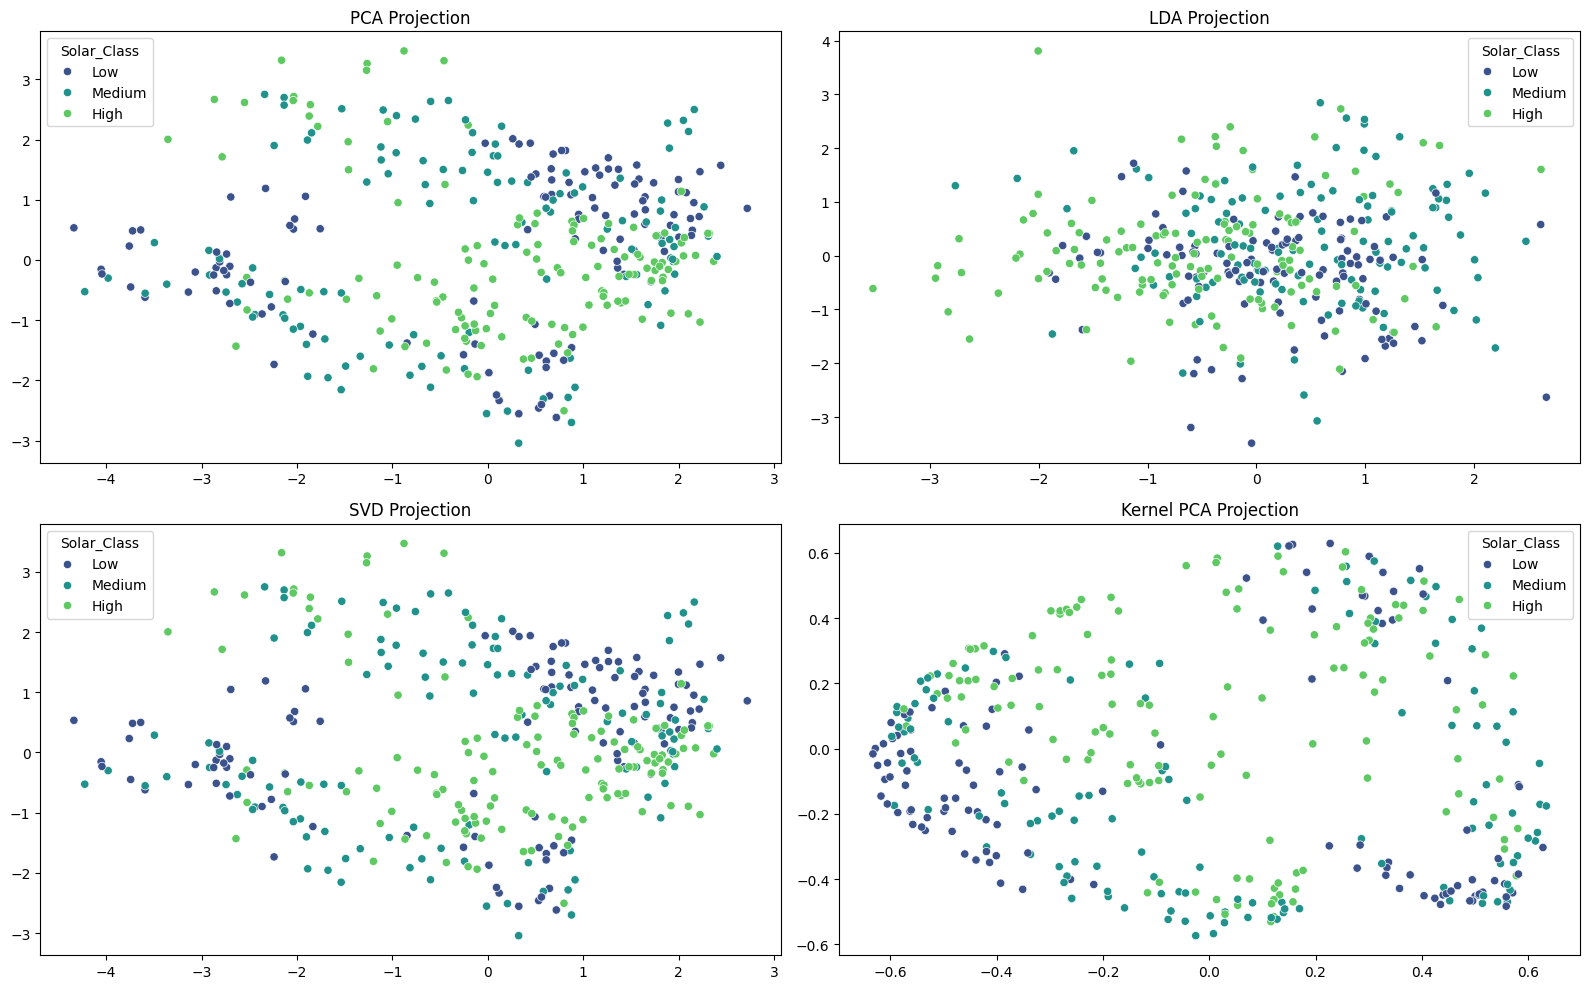

In [ ]:

print("\n--- 1. Advanced Feature Reduction ---")


features_new = ['AvgTemperture', 'AverageDew(point via humidity)', 'Humidity', 'Wind', 'Pressure', 'Month']
X_new = df[features_new]
X_scaled_new = scaler.fit_transform(X_new)
y_encoded = le.fit_transform(df['Solar_Class'])


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_new)


lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled_new, y_encoded)


svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_scaled_new)


kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled_new)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.4f}")
print(f"LDA Explained Variance Ratio: {lda.explained_variance_ratio_.sum():.4f}")


print(f"SVD Explained Variance Ratio: {svd.explained_variance_ratio_.sum():.4f}")


plt.figure(figsize=(16, 10))
methods = [('PCA', X_pca), ('LDA', X_lda), ('SVD', X_svd), ('Kernel PCA', X_kpca)]

for i, (name, data) in enumerate(methods):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=df['Solar_Class'], palette='viridis')
    plt.title(f'{name} Projection')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 4: Model Implementations with Validation vs Test Accuracy
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n--- 2. Models & Dual-Validation Evaluation ---")


X_temp, X_test, y_temp, y_test = train_test_split(X_scaled_new, y_encoded, test_size=0.2, random_state=42)


X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)


all_clf_models = {
    'Naive Bayes': GaussianNB(),
    'Decision Tree (Entropy)': DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42),
    'LDA Classifier': LDA(),
    'K-NN (Manhattan)': KNeighborsClassifier(n_neighbors=7, metric='manhattan'),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=2000, random_state=42)
}


print(f"{'Model':<25} | {'CV Avg Accuracy':<15}")
print("-" * 45)
for name, model in all_clf_models.items():
    cv_scores = cross_val_score(model, X_scaled_new, y_encoded, cv=5) #
    print(f"{name:<25} | {cv_scores.mean():.4f}")


final_comparison = []

print("\n" + "="*65)
print(f"{'Model Name':<25} | {'Val Acc':<12} | {'Final Test Acc':<15}")
print("="*65)

for name, model in all_clf_models.items():

    model.fit(X_train, y_train)


    val_acc = accuracy_score(y_val, model.predict(X_val))


    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"{name:<25} | {val_acc:.4f}     | {test_acc:.4f}")

    final_comparison.append({
        'Model': name,
        'Accuracy': f"{test_acc:.4f}",
        'Error Rate': f"{1-test_acc:.4f}" #
    })


print("\n--- Linear Regression Performance ---")
y_reg = df['Solar(PV)']
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(X_scaled_new, y_reg, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_tr_reg, y_tr_reg)
y_pred_reg = lin_reg.predict(X_te_reg)

print(f"MAE: {mean_absolute_error(y_te_reg, y_pred_reg):.4f} | RMSE: {np.sqrt(mean_squared_error(y_te_reg, y_pred_reg)):.4f}") #

print("\n--- Final Comparison Summary (Test Data) ---")
print(pd.DataFrame(final_comparison))


--- 2. Models & Dual-Validation Evaluation ---
Model                     | CV Avg Accuracy
---------------------------------------------
Naive Bayes               | 0.1838
Decision Tree (Entropy)   | 0.4877
LDA Classifier            | 0.2540
K-NN (Manhattan)          | 0.4276
Logistic Regression       | 0.2565
Neural Network (MLP)      | 0.4928

Model Name                | Val Acc      | Final Test Acc 
Naive Bayes               | 0.5000     | 0.4250
Decision Tree (Entropy)   | 0.6719     | 0.7125
LDA Classifier            | 0.4688     | 0.4875
K-NN (Manhattan)          | 0.6719     | 0.6375
Logistic Regression       | 0.5156     | 0.4750
Neural Network (MLP)      | 0.7188     | 0.7375

--- Linear Regression Performance ---
MAE: 6.1853 | RMSE: 7.2579

--- Final Comparison Summary (Test Data) ---
                     Model Accuracy Error Rate
0              Naive Bayes   0.4250     0.5750
1  Decision Tree (Entropy)   0.7125     0.2875
2           LDA Classifier   0.4875     0.5125
3   


--- 3. Final Model Evaluation & Overfitting Analysis ---
Final Model Selected: Neural Network (MLP)
Final Test Accuracy: 0.7375 | Final Test Error Rate: 0.2625

--- Interpreting Confusion Matrix ---


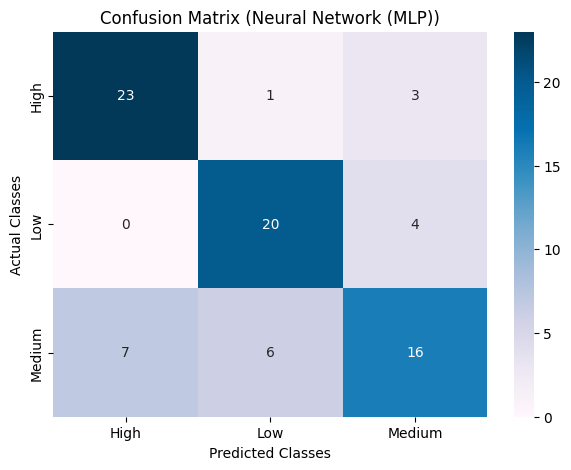


--- Generating Learning Curves (Overfitting/Underfitting Check) ---


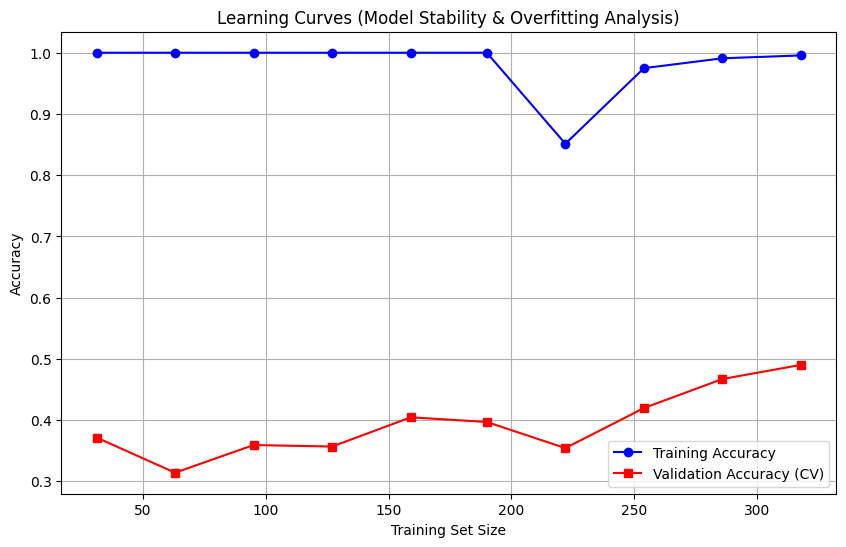


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        High       0.77      0.85      0.81        27
         Low       0.74      0.83      0.78        24
      Medium       0.70      0.55      0.62        29

    accuracy                           0.74        80
   macro avg       0.73      0.75      0.74        80
weighted avg       0.73      0.74      0.73        80



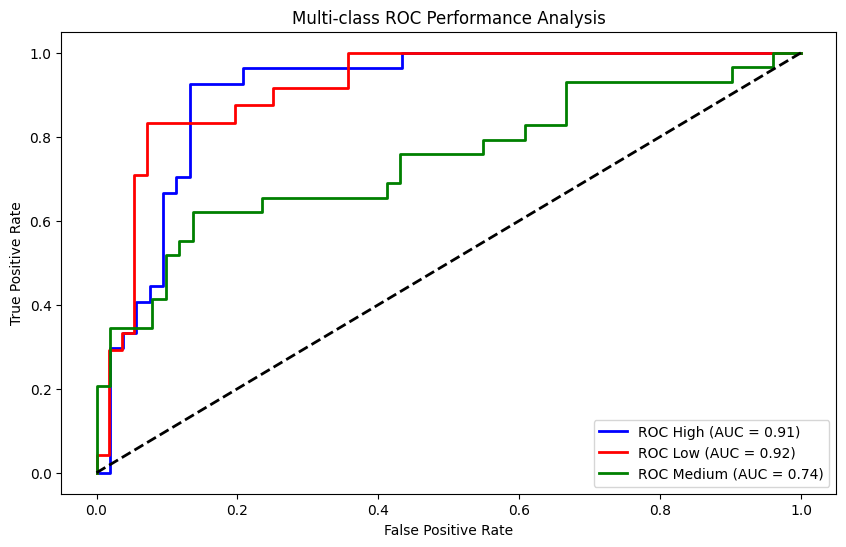


--- Final Summary Table (All Models Performance) ---
                     Model Final Test Accuracy Error Rate
0              Naive Bayes              0.4250     0.5750
1  Decision Tree (Entropy)              0.7125     0.2875
2           LDA Classifier              0.4875     0.5125
3         K-NN (Manhattan)              0.6375     0.3625
4      Logistic Regression              0.4750     0.5250
5     Neural Network (MLP)              0.7375     0.2625

*Final Interpretation: The results show the model's performance across different evaluation metrics.


In [ ]:

print("\n--- 3. Final Model Evaluation & Overfitting Analysis ---")

from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import label_binarize


final_model_name = 'Neural Network (MLP)'
final_model = all_clf_models[final_model_name]


y_pred = final_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)
final_error = 1 - final_acc

print(f"Final Model Selected: {final_model_name}")
print(f"Final Test Accuracy: {final_acc:.4f} | Final Test Error Rate: {final_error:.4f}")


print("\n--- Interpreting Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix ({final_model_name})')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()


print("\n--- Generating Learning Curves (Overfitting/Underfitting Check) ---")
train_sizes, train_scores, test_scores = learning_curve(
    final_model, X_scaled_new, y_encoded, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)



plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Accuracy', color='blue', marker='o')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Accuracy (CV)', color='red', marker='s')
plt.title('Learning Curves (Model Stability & Overfitting Analysis)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()


print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))


y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = final_model.predict_proba(X_test)

plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green']
for i, label in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, lw=2, color=colors[i], label=f'ROC {label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC Performance Analysis')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


comparison_list = []
for name, model in all_clf_models.items():
    test_acc = accuracy_score(y_test, model.predict(X_test))
    comparison_list.append({
        'Model': name,
        'Final Test Accuracy': f"{test_acc:.4f}",
        'Error Rate': f"{1-test_acc:.4f}"
    })

print("\n--- Final Summary Table (All Models Performance) ---")
summary_df = pd.DataFrame(comparison_list)
print(summary_df)

print("\n*Final Interpretation: The results show the model's performance across different evaluation metrics.")